In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

##### Load dữ liệu đã xử lý (từ 03_preprocessing.ipynb)

In [12]:
import joblib

# Import train/val/test đã scale + scaler đã lưu từ 03_preprocessing.ipynb thay vì lặp lại pipeline
train_scaled = pd.read_csv('data/processed/train_scaled.csv', index_col='time', parse_dates=True)
val_scaled = pd.read_csv('data/processed/val_scaled.csv', index_col='time', parse_dates=True)
test_scaled = pd.read_csv('data/processed/test_scaled.csv', index_col='time', parse_dates=True)
scaler = joblib.load('data/processed/scaler.joblib')

feature_cols = train_scaled.columns.tolist()
pm25_col_idx = feature_cols.index('PM2.5')
n_features = len(feature_cols)

print(f"Train: {len(train_scaled)} dòng | Val: {len(val_scaled)} dòng | Test: {len(test_scaled)} dòng")
print(f"Feature columns ({n_features}): {feature_cols}")

Train: 24405 dòng | Val: 5230 dòng | Test: 5230 dòng
Feature columns (11): ['PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide', 'Ozone', 'Aerosol Optical Depth', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


##### Model & Training Utilities

In [13]:
def create_sequences(data, target_col_idx, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + horizon - 1, target_col_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def train_model(train_scaled, val_scaled, pm25_col_idx, window_size, hidden_size=32,
                 num_layers=2, dropout=0.2, lr=1e-3, batch_size=256,
                 max_epochs=20, patience=4, device='cpu', verbose=False):
    X_train, y_train = create_sequences(train_scaled.values, pm25_col_idx, window_size)
    X_val, y_val = create_sequences(val_scaled.values, pm25_col_idx, window_size)

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = GRUModel(input_size=X_train.shape[2], hidden_size=hidden_size,
                      num_layers=num_layers, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()  # MAE thay vì MSE: khớp với metric đánh giá cuối, ít bị outlier/cú giật chi phối hơn

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(criterion(pred, yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if verbose:
            print(f"  Epoch {epoch + 1}/{max_epochs} - train_loss={train_loss:.5f}, val_loss={val_loss:.5f}")

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss, history

##### Hyperparameter Tuning: Window Size, Hidden Size, Learning Rate

In [14]:
# Mở rộng grid search: window_size x hidden_size x learning_rate (bỏ window=72h vì đã thua ở 2 lần search
# trước, tập trung ngân sách tính toán vào vùng có triển vọng hơn để mở rộng thêm 2 chiều mới).
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

window_candidates = [24, 48]
hidden_candidates = [32, 64]
lr_candidates = [1e-3, 5e-4]

search_results = []
for ws in window_candidates:
    for hs in hidden_candidates:
        for lr in lr_candidates:
            print(f"Đang thử window={ws}h, hidden={hs}, lr={lr}...")
            _, val_loss, _ = train_model(
                train_scaled, val_scaled, pm25_col_idx,
                window_size=ws, hidden_size=hs, lr=lr, max_epochs=6, patience=2, device=device,
            )
            search_results.append({'window_size': ws, 'hidden_size': hs, 'lr': lr, 'val_loss': val_loss})
            print(f"  -> val_loss (MAE, thang đo scaled) = {val_loss:.5f}")

results_df = pd.DataFrame(search_results).sort_values('val_loss').reset_index(drop=True)
results_df

Device: cpu
Đang thử window=24h, hidden=32, lr=0.001...
  -> val_loss (MAE, thang đo scaled) = 0.01431
Đang thử window=24h, hidden=32, lr=0.0005...
  -> val_loss (MAE, thang đo scaled) = 0.01801
Đang thử window=24h, hidden=64, lr=0.001...
  -> val_loss (MAE, thang đo scaled) = 0.01390
Đang thử window=24h, hidden=64, lr=0.0005...
  -> val_loss (MAE, thang đo scaled) = 0.01502
Đang thử window=48h, hidden=32, lr=0.001...
  -> val_loss (MAE, thang đo scaled) = 0.01410
Đang thử window=48h, hidden=32, lr=0.0005...
  -> val_loss (MAE, thang đo scaled) = 0.01852
Đang thử window=48h, hidden=64, lr=0.001...
  -> val_loss (MAE, thang đo scaled) = 0.01276
Đang thử window=48h, hidden=64, lr=0.0005...
  -> val_loss (MAE, thang đo scaled) = 0.01738


,window_size,hidden_size,lr,val_loss
0,48,64,0.0010,0.012756
1,24,64,0.0010,0.013899
2,48,32,0.0010,0.014102
3,24,32,0.0010,0.014307
4,24,64,0.0005,0.015019
5,48,64,0.0005,0.017382
6,24,32,0.0005,0.018011
7,48,32,0.0005,0.018523


In [15]:
# Chọn cấu hình "nhẹ" nhất (cost = window_size x hidden_size, proxy cho chi phí tính toán của GRU) trong
# số các cấu hình có val_loss gần mức tốt nhất (trong khoảng dung sai TOLERANCE)
TOLERANCE = 0.10  # 10%
best_val_loss = results_df['val_loss'].min()
candidates = results_df[results_df['val_loss'] <= best_val_loss * (1 + TOLERANCE)].copy()
candidates['cost'] = candidates['window_size'] * candidates['hidden_size']
best_row = candidates.sort_values('cost').iloc[0]

BEST_WINDOW = int(best_row['window_size'])
BEST_HIDDEN = int(best_row['hidden_size'])
BEST_LR = float(best_row['lr'])

print(f"Các cấu hình trong khoảng {TOLERANCE * 100:.0f}% so với tốt nhất ({best_val_loss:.5f}):")
print(candidates.sort_values('cost').to_string(index=False))
print(f"\nCấu hình được chọn: window={BEST_WINDOW}h, hidden_size={BEST_HIDDEN}, lr={BEST_LR} "
      f"(val_loss={best_row['val_loss']:.5f})")

Các cấu hình trong khoảng 10% so với tốt nhất (0.01276):
 window_size  hidden_size    lr  val_loss  cost
          24           64 0.001  0.013899  1536
          48           64 0.001  0.012756  3072

Cấu hình được chọn: window=24h, hidden_size=64, lr=0.001 (val_loss=0.01390)


##### Train Model Cuối Cùng (cấu hình tốt nhất, nhiều epoch hơn)

  Epoch 1/25 - train_loss=0.04880, val_loss=0.02513
  Epoch 2/25 - train_loss=0.02452, val_loss=0.02012
  Epoch 3/25 - train_loss=0.02004, val_loss=0.01767
  Epoch 4/25 - train_loss=0.01741, val_loss=0.01430
  Epoch 5/25 - train_loss=0.01573, val_loss=0.01292
  Epoch 6/25 - train_loss=0.01435, val_loss=0.01391
  Epoch 7/25 - train_loss=0.01397, val_loss=0.01252
  Epoch 8/25 - train_loss=0.01366, val_loss=0.01147
  Epoch 9/25 - train_loss=0.01364, val_loss=0.01185
  Epoch 10/25 - train_loss=0.01304, val_loss=0.01140
  Epoch 11/25 - train_loss=0.01317, val_loss=0.01203
  Epoch 12/25 - train_loss=0.01270, val_loss=0.01144
  Epoch 13/25 - train_loss=0.01285, val_loss=0.01220
  Epoch 14/25 - train_loss=0.01261, val_loss=0.01365
  Epoch 15/25 - train_loss=0.01257, val_loss=0.01171


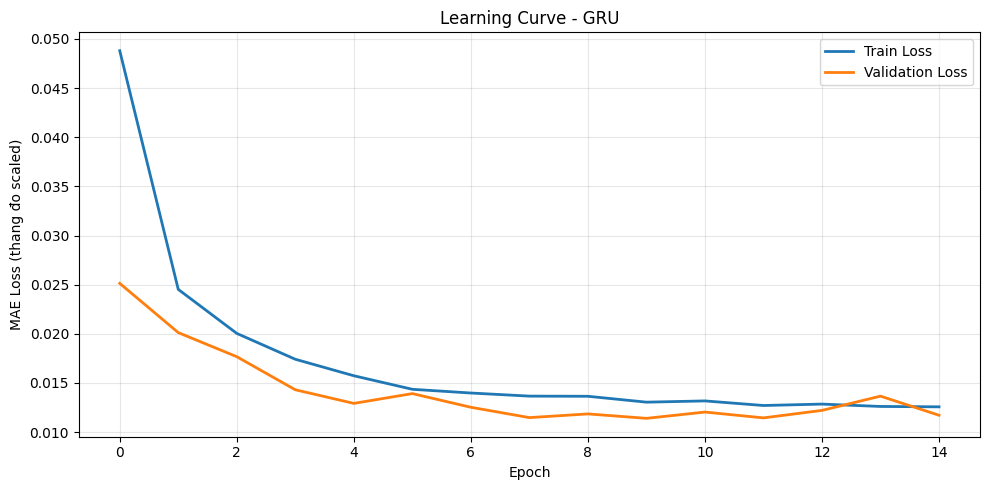

In [16]:
final_model, final_val_loss, history = train_model(
    train_scaled, val_scaled, pm25_col_idx,
    window_size=BEST_WINDOW, hidden_size=BEST_HIDDEN, lr=BEST_LR, max_epochs=25, patience=5,
    device=device, verbose=True,
)

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE Loss (thang đo scaled)')
plt.title('Learning Curve - GRU')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Đánh giá trên Test Set: GRU vs Baseline

In [17]:
X_test, y_test = create_sequences(test_scaled.values, pm25_col_idx, BEST_WINDOW)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=256, shuffle=False)

final_model.eval()
preds_scaled = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds_scaled.append(final_model(xb).cpu().numpy())
preds_scaled = np.concatenate(preds_scaled)


def inverse_transform_col(scaled_values, col_idx, scaler, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, col_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, col_idx]


pred_pm25 = inverse_transform_col(preds_scaled, pm25_col_idx, scaler, n_features)
true_pm25 = inverse_transform_col(y_test, pm25_col_idx, scaler, n_features)

# Mốc thời gian tương ứng với từng dự báo: target đầu tiên rơi vào vị trí BEST_WINDOW của test_scaled
target_times = test_scaled.index[BEST_WINDOW:BEST_WINDOW + len(y_test)]

# PM2.5 thang đo gốc cho toàn bộ test set (để tính baseline) - inverse-transform từ test_scaled
test_pm25_series = pd.Series(
    inverse_transform_col(test_scaled['PM2.5'].values, pm25_col_idx, scaler, n_features),
    index=test_scaled.index,
)


def mae_rmse(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse


# Baseline: Naive (giá trị giờ trước) & Seasonal Naive (giá trị cùng giờ hôm qua, lag=24)
# Đánh giá trên CÙNG target_times với GRU để so sánh công bằng
naive_pred = test_pm25_series.shift(1).loc[target_times].values
seasonal_pred = test_pm25_series.shift(24).loc[target_times].values

mae_naive, rmse_naive = mae_rmse(true_pm25, naive_pred)
mae_seasonal, rmse_seasonal = mae_rmse(true_pm25, seasonal_pred)
mae_gru, rmse_gru = mae_rmse(true_pm25, pred_pm25)

comparison = pd.DataFrame({
    'Model': ['Naive (t-1)', 'Seasonal Naive (t-24)', f'GRU (window={BEST_WINDOW}h)'],
    'MAE (µg/m³)': [mae_naive, mae_seasonal, mae_gru],
    'RMSE (µg/m³)': [rmse_naive, rmse_seasonal, rmse_gru],
})
comparison

,Model,MAE (µg/m³),RMSE (µg/m³)
0,Naive (t-1),1.322916,2.341484
1,Seasonal Naive (t-24),4.699385,6.690829
2,GRU (window=24h),1.171696,2.173016


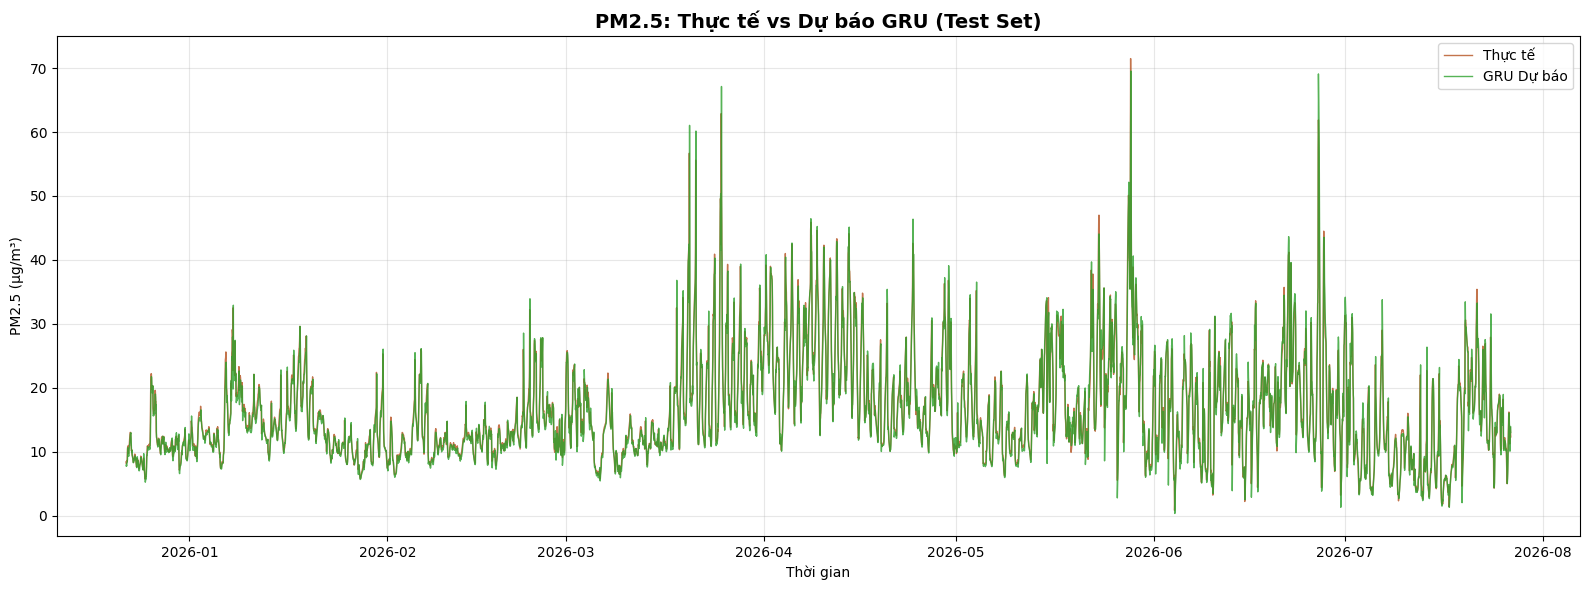

In [20]:
plt.figure(figsize=(16, 6))
plt.plot(target_times, true_pm25, label='Thực tế', color="#b4511f", alpha=0.8, linewidth=1)
plt.plot(target_times, pred_pm25, label='GRU Dự báo', color='#2ca02c', alpha=0.8, linewidth=1)
plt.xlabel('Thời gian')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('PM2.5: Thực tế vs Dự báo GRU (Test Set)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Residual Diagnostics

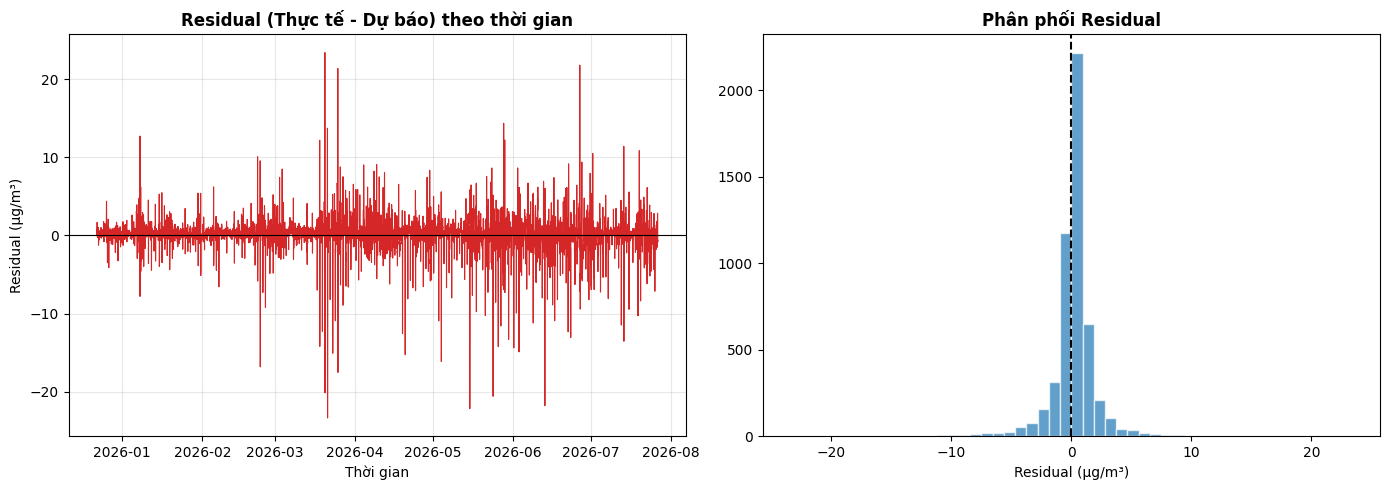

Residual mean: 0.175 µg/m³, std: 2.166 µg/m³


In [19]:
residuals = true_pm25 - pred_pm25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(target_times, residuals, linewidth=0.8, color='#d62728')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residual (Thực tế - Dự báo) theo thời gian', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Thời gian')
axes[0].set_ylabel('Residual (µg/m³)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=50, color='#1f77b4', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Phân phối Residual', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (µg/m³)')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.3f} µg/m³, std: {residuals.std():.3f} µg/m³")

##### Lưu Model để dùng ở notebook khác (05_new_data_evaluation.ipynb)

In [ ]:
import os

# Lưu trọng số model + config kiến trúc (cần thiết để dựng lại đúng GRUModel trước khi load_state_dict)
# để 05_new_data_evaluation.ipynb dùng lại đúng model đã train ở đây, không phải train lại từ đầu.
os.makedirs('data/processed', exist_ok=True)
torch.save({
    'model_state_dict': final_model.state_dict(),
    'window_size': BEST_WINDOW,
    'hidden_size': BEST_HIDDEN,
    'num_layers': 2,
    'dropout': 0.2,
    'lr': BEST_LR,
}, 'data/processed/gru_model.pt')

print("Đã lưu model vào data/processed/gru_model.pt")